<div align="center">
<h1><b> Demand Prediction Agent </b></h1>
</div>

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib

# Setting up the visualisation parameters
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

In [2]:
# Load Data
urban = pd.read_csv('../data/processed/clean_urban_data.csv', parse_dates=['datetime'])
acn   = pd.read_csv('../data/processed/clean_acn_data.csv',   parse_dates=['connectionTime'])

print("Urban EV:", urban.shape)
print("ACN Data:", acn.shape)
print("\nUrban columns:", urban.columns.tolist())

'''Urban EV is the primary dataset for demand prediction — 2.1M rows with 5-minute granularity
across 247 stations gives enough data for robust ML modelling. ACN is loaded for reference'''

Urban EV: (2134080, 32)
ACN Data: (15013, 29)

Urban columns: ['slot_index', 'station_id', 'occupancy', 'volume', 'price_multiplier', 'avg_duration_hrs', 'datetime', 'longitude', 'latitude', 'total_chargers', 'fast_chargers', 'slow_chargers', 'area_sqkm', 'is_cbd', 'has_dynamic_pricing', 'hour', 'minute', 'day_of_week', 'day_name', 'date', 'is_weekend', 'month', 'week', 'period', 'charger_utilization_rate', 'price_cny_kwh', 'revenue_proxy', 'queue_proxy', 'occupancy_density', 'has_fast_charger', 'is_congested', 'is_underutilized']


'Urban EV is the primary dataset for demand prediction — 2.1M rows with 5-minute granularity\nacross 247 stations gives enough data for robust ML modelling. ACN is loaded for reference'

In [3]:
# ============================================================
# FORECAST HORIZON = 12 slots = 1 hour ahead (Since one slot corresponds to 5 minute interval)
# At time t, we predict utilization at time t+12
# This is the correct framing for dynamic tariff optimization
# ============================================================

FORECAST_HORIZON = 12  # slots (each slot = 5 minutes → 12 slots = 1 hour)

urban_sorted = urban.sort_values(['station_id', 'datetime']).copy()
urban_sorted['period_enc'] = urban_sorted['period'].map(
    {'peak': 2, 'shoulder': 1, 'off_peak': 0}
)

# TARGET: utilization 1 hour INTO THE FUTURE per station
urban_sorted['target_utilization_1hr'] = (
    urban_sorted.groupby('station_id')['charger_utilization_rate']
    .shift(-FORECAST_HORIZON)   # negative shift = look forward
)

print(f"Forecast horizon: {FORECAST_HORIZON} slots = 1 hour ahead")
print(f"Target column: 'target_utilization_1hr'")
print(urban_sorted[['datetime','station_id',
                     'charger_utilization_rate',
                     'target_utilization_1hr']].head(15).to_string(index=False))

Forecast horizon: 12 slots = 1 hour ahead
Target column: 'target_utilization_1hr'
           datetime  station_id  charger_utilization_rate  target_utilization_1hr
2022-06-19 00:00:00         102                       0.4                     0.4
2022-06-19 00:05:00         102                       0.4                     0.4
2022-06-19 00:10:00         102                       0.4                     0.4
2022-06-19 00:15:00         102                       0.4                     0.4
2022-06-19 00:20:00         102                       0.4                     0.4
2022-06-19 00:25:00         102                       0.4                     0.4
2022-06-19 00:30:00         102                       0.4                     0.4
2022-06-19 00:35:00         102                       0.4                     0.4
2022-06-19 00:40:00         102                       0.4                     0.4
2022-06-19 00:45:00         102                       0.4                     0.4
2022-06-19 00:50

In [4]:
# LAG FEATURES — all look BACKWARD (past data only)
# Lag features give the model historical context without leaking future information.
# These are all legitimate — no future information used
# Lag 12 slots = current utilization (1 hour before target)
urban_sorted['util_now'] = (
    urban_sorted.groupby('station_id')['charger_utilization_rate']
    .shift(0)  # current slot = 1 hour before our target
)

# Lag 12 slots = 1 hour ago from current
urban_sorted['util_1hr_ago'] = (
    urban_sorted.groupby('station_id')['charger_utilization_rate']
    .shift(12)
)

# Lag 24 slots = 2 hours ago
urban_sorted['util_2hr_ago'] = (
    urban_sorted.groupby('station_id')['charger_utilization_rate']
    .shift(24)
)

# Lag 288 slots = same hour yesterday
urban_sorted['util_yesterday_same_hour'] = (
    urban_sorted.groupby('station_id')['charger_utilization_rate']
    .shift(288)
)

# Rolling mean — last 1 hour (12 slots) of PAST data
urban_sorted['util_rolling_1hr'] = (
    urban_sorted.groupby('station_id')['charger_utilization_rate']
    .transform(lambda x: x.rolling(12, min_periods=3).mean())
)

# Rolling std — demand volatility in last 1 hour
urban_sorted['util_rolling_std_1hr'] = (
    urban_sorted.groupby('station_id')['charger_utilization_rate']
    .transform(lambda x: x.rolling(12, min_periods=3).std())
)

# Rolling mean — last 24 hours
urban_sorted['util_rolling_24hr'] = (
    urban_sorted.groupby('station_id')['charger_utilization_rate']
    .transform(lambda x: x.rolling(288, min_periods=12).mean())
)

print("Lag features created")
print(urban_sorted[['datetime','util_now','util_1hr_ago',
                     'util_yesterday_same_hour',
                     'target_utilization_1hr']].head(20).to_string(index=False))

Lag features created
           datetime  util_now  util_1hr_ago  util_yesterday_same_hour  target_utilization_1hr
2022-06-19 00:00:00       0.4           NaN                       NaN                     0.4
2022-06-19 00:05:00       0.4           NaN                       NaN                     0.4
2022-06-19 00:10:00       0.4           NaN                       NaN                     0.4
2022-06-19 00:15:00       0.4           NaN                       NaN                     0.4
2022-06-19 00:20:00       0.4           NaN                       NaN                     0.4
2022-06-19 00:25:00       0.4           NaN                       NaN                     0.4
2022-06-19 00:30:00       0.4           NaN                       NaN                     0.4
2022-06-19 00:35:00       0.4           NaN                       NaN                     0.4
2022-06-19 00:40:00       0.4           NaN                       NaN                     0.4
2022-06-19 00:45:00       0.4          

In [5]:
# Final clean feature set — NO leakage

feature_cols = [
    # Time features
    'hour', 'minute', 'day_of_week', 'is_weekend', 'month', 'week', 'period_enc',

    # Station static features
    'total_chargers', 'fast_chargers', 'slow_chargers',
    'has_fast_charger', 'is_cbd', 'area_sqkm',

    # External signal
    'price_multiplier',

    # Legitimate lag features (all look backward)
    'util_now',                    # current utilization (1hr before target)
    'util_1hr_ago',                # 1 hour ago
    'util_2hr_ago',                # 2 hours ago
    'util_yesterday_same_hour',    # same time yesterday
    'util_rolling_1hr',            # 1hr rolling mean
    'util_rolling_std_1hr',        # 1hr rolling std (volatility)
    'util_rolling_24hr',           # 24hr rolling mean
]

target_col = 'target_utilization_1hr'

# Build model dataframe
model_df = urban_sorted[
    feature_cols + [target_col, 'datetime', 'station_id']
].dropna()

print("Model dataset shape:", model_df.shape)
print(f"   Rows dropped (NaN from lags/target): "
      f"{len(urban_sorted) - len(model_df):,}")

print("\nFeature count:", len(feature_cols))
print("Target: predict utilization 1 HOUR AHEAD")
print("\nTarget stats:")
print(model_df[target_col].describe().round(4))


# Time-based split — last 20% as test
model_df   = model_df.sort_values('datetime').reset_index(drop=True)
split_idx  = int(len(model_df) * 0.80)
split_date = model_df.loc[split_idx, 'datetime']

train = model_df.iloc[:split_idx]
test  = model_df.iloc[split_idx:]

X_train = train[feature_cols]
y_train = train[target_col]
X_test  = test[feature_cols]
y_test  = test[target_col]

print(f"\nTrain: {len(train):,} rows | {train['datetime'].min()} → {train['datetime'].max()}")
print(f"Test:  {len(test):,} rows  | {test['datetime'].min()} → {test['datetime'].max()}")
print(f"Split date: {split_date}")

Model dataset shape: (2059980, 24)
   Rows dropped (NaN from lags/target): 74,100

Feature count: 21
Target: predict utilization 1 HOUR AHEAD

Target stats:
count    2.059980e+06
mean     2.803000e-01
std      1.760000e-01
min      0.000000e+00
25%      1.522000e-01
50%      2.500000e-01
75%      3.778000e-01
max      1.000000e+00
Name: target_utilization_1hr, dtype: float64

Train: 1,647,984 rows | 2022-06-20 00:00:00 → 2022-07-13 03:55:00
Test:  411,996 rows  | 2022-07-13 04:00:00 → 2022-07-18 22:55:00
Split date: 2022-07-13 04:00:00


In [6]:
# Definition of Models:

models = {
    'XGBoost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'Ridge': Ridge(alpha=1.0)
}

print("Models defined:")
for name in models:
    print(f"   - {name}")

Models defined:
   - XGBoost
   - LightGBM
   - RandomForest
   - Ridge


In [7]:
# Training and Evaluation of all the models
results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds = np.clip(preds, 0, 1)  # utilization rate must be 0-1
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    
    results.append({
        'Model': name,
        'RMSE':  round(rmse, 5),
        'MAE':   round(mae,  5),
        'R2':    round(r2,   5)
    })
    trained_models[name] = (model, preds)
    print(f"RMSE: {rmse:.5f} | MAE: {mae:.5f} | R²: {r2:.5f}")

scores_df = pd.DataFrame(results).sort_values('RMSE')
print("\n=== Model Comparison ===")
print(scores_df.to_string(index=False))

# Save scores
scores_df.to_csv('../outputs/demand_agent/demand_model_scores.csv', index=False)
print("\nSaved: demand_model_scores.csv")

Training XGBoost... RMSE: 0.05005 | MAE: 0.02976 | R²: 0.91900
Training LightGBM... RMSE: 0.05075 | MAE: 0.03020 | R²: 0.91675
Training RandomForest... RMSE: 0.05570 | MAE: 0.03233 | R²: 0.89970
Training Ridge... RMSE: 0.06138 | MAE: 0.03615 | R²: 0.87820

=== Model Comparison ===
       Model    RMSE     MAE      R2
     XGBoost 0.05005 0.02976 0.91900
    LightGBM 0.05075 0.03020 0.91675
RandomForest 0.05570 0.03233 0.89970
       Ridge 0.06138 0.03615 0.87820

Saved: demand_model_scores.csv


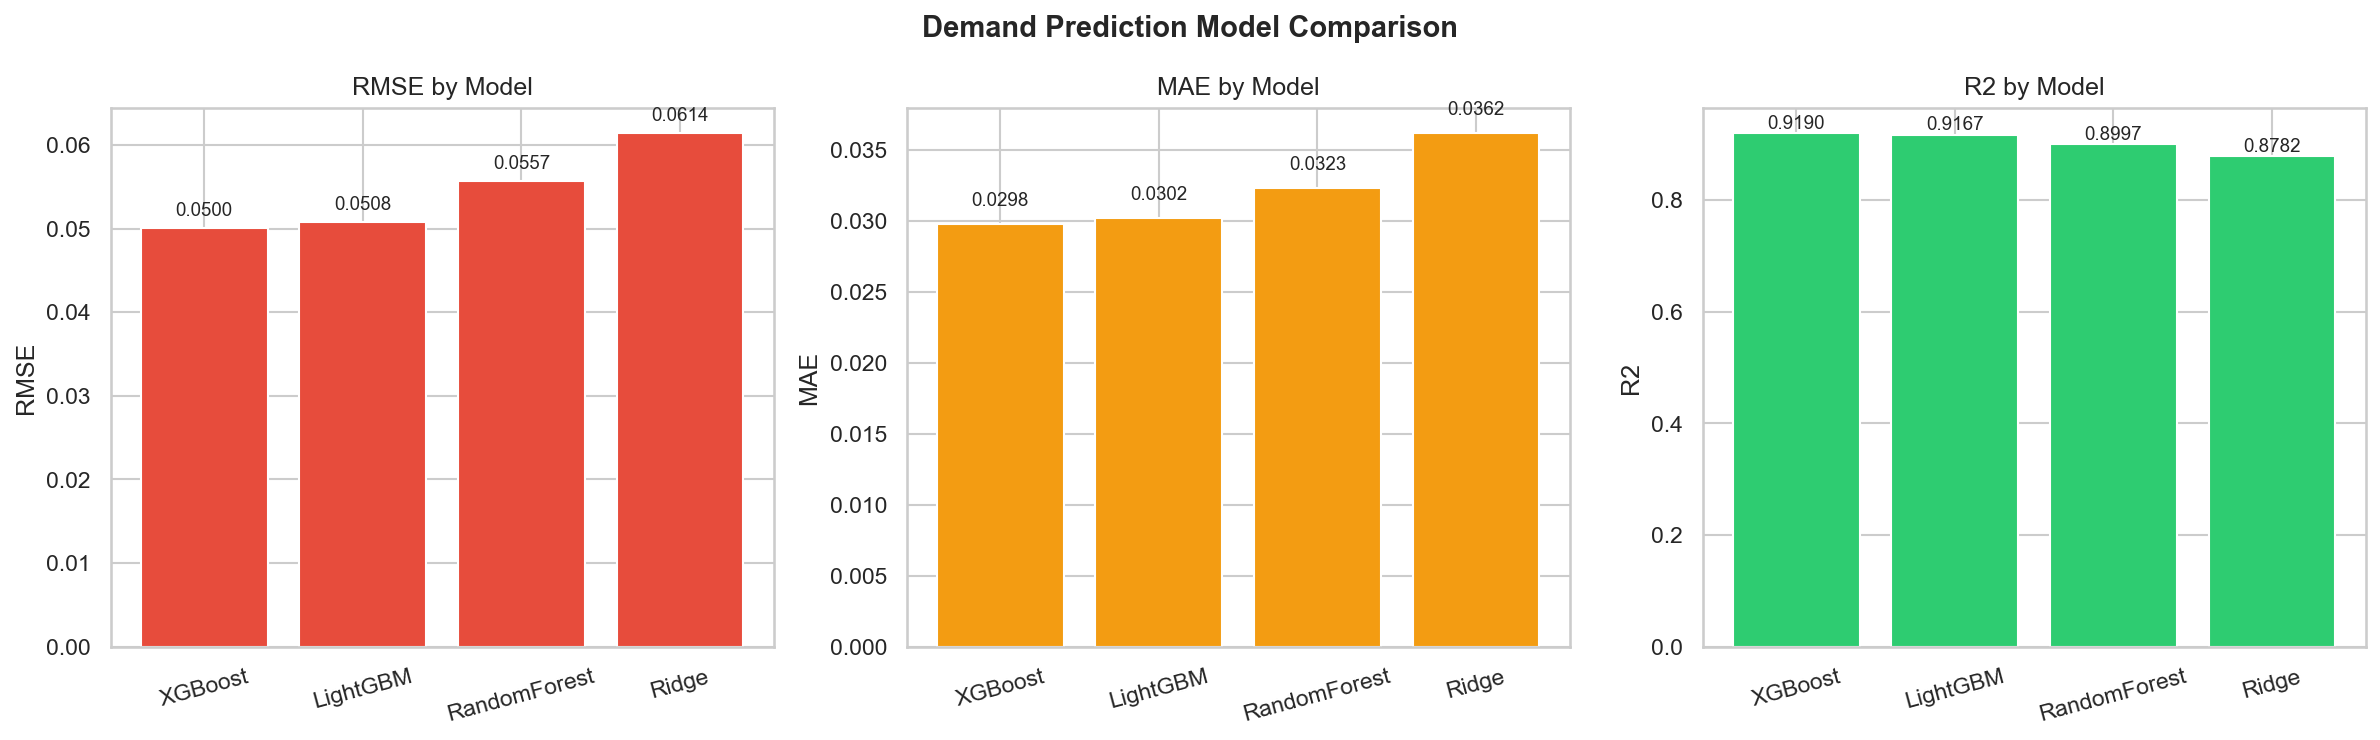

Saved: model_comparison.png


In [8]:
# Visualise model comparison 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['RMSE', 'MAE', 'R2']
colors  = ['#e74c3c', '#f39c12', '#2ecc71']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = axes[i].bar(
        scores_df['Model'],
        scores_df[metric],
        color=color,
        edgecolor='white'
    )
    axes[i].set_title(f'{metric} by Model')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

    # Label bars
    for bar, val in zip(bars, scores_df[metric]):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Demand Prediction Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/demand_agent/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

In [9]:
# Selection of best model and saving it
# Best model = lowest RMSE
best_name = scores_df.iloc[0]['Model']
best_model, best_preds = trained_models[best_name]

print(f"   Best Model: {best_name}")
print(f"   RMSE: {scores_df.iloc[0]['RMSE']}")
print(f"   MAE:  {scores_df.iloc[0]['MAE']}")
print(f"   R²:   {scores_df.iloc[0]['R2']}")

# Save best model
model_path = f'../models/demand_prediction/{best_name.lower()}_demand_model.pkl'
joblib.dump(best_model, model_path)
print(f"\nModel saved: {model_path}")

# Save model config
import json
config = {
    'best_model':   best_name,
    'features':     feature_cols,
    'target':       target_col,
    'train_size':   len(train),
    'test_size':    len(test),
    'split_date':   str(split_date),
    'rmse':         scores_df.iloc[0]['RMSE'],
    'mae':          scores_df.iloc[0]['MAE'],
    'r2':           scores_df.iloc[0]['R2']
}
with open('../models/demand_prediction/model_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print("Config saved: model_config.json")

   Best Model: XGBoost
   RMSE: 0.05005
   MAE:  0.02976
   R²:   0.919

Model saved: ../models/demand_prediction/xgboost_demand_model.pkl
Config saved: model_config.json


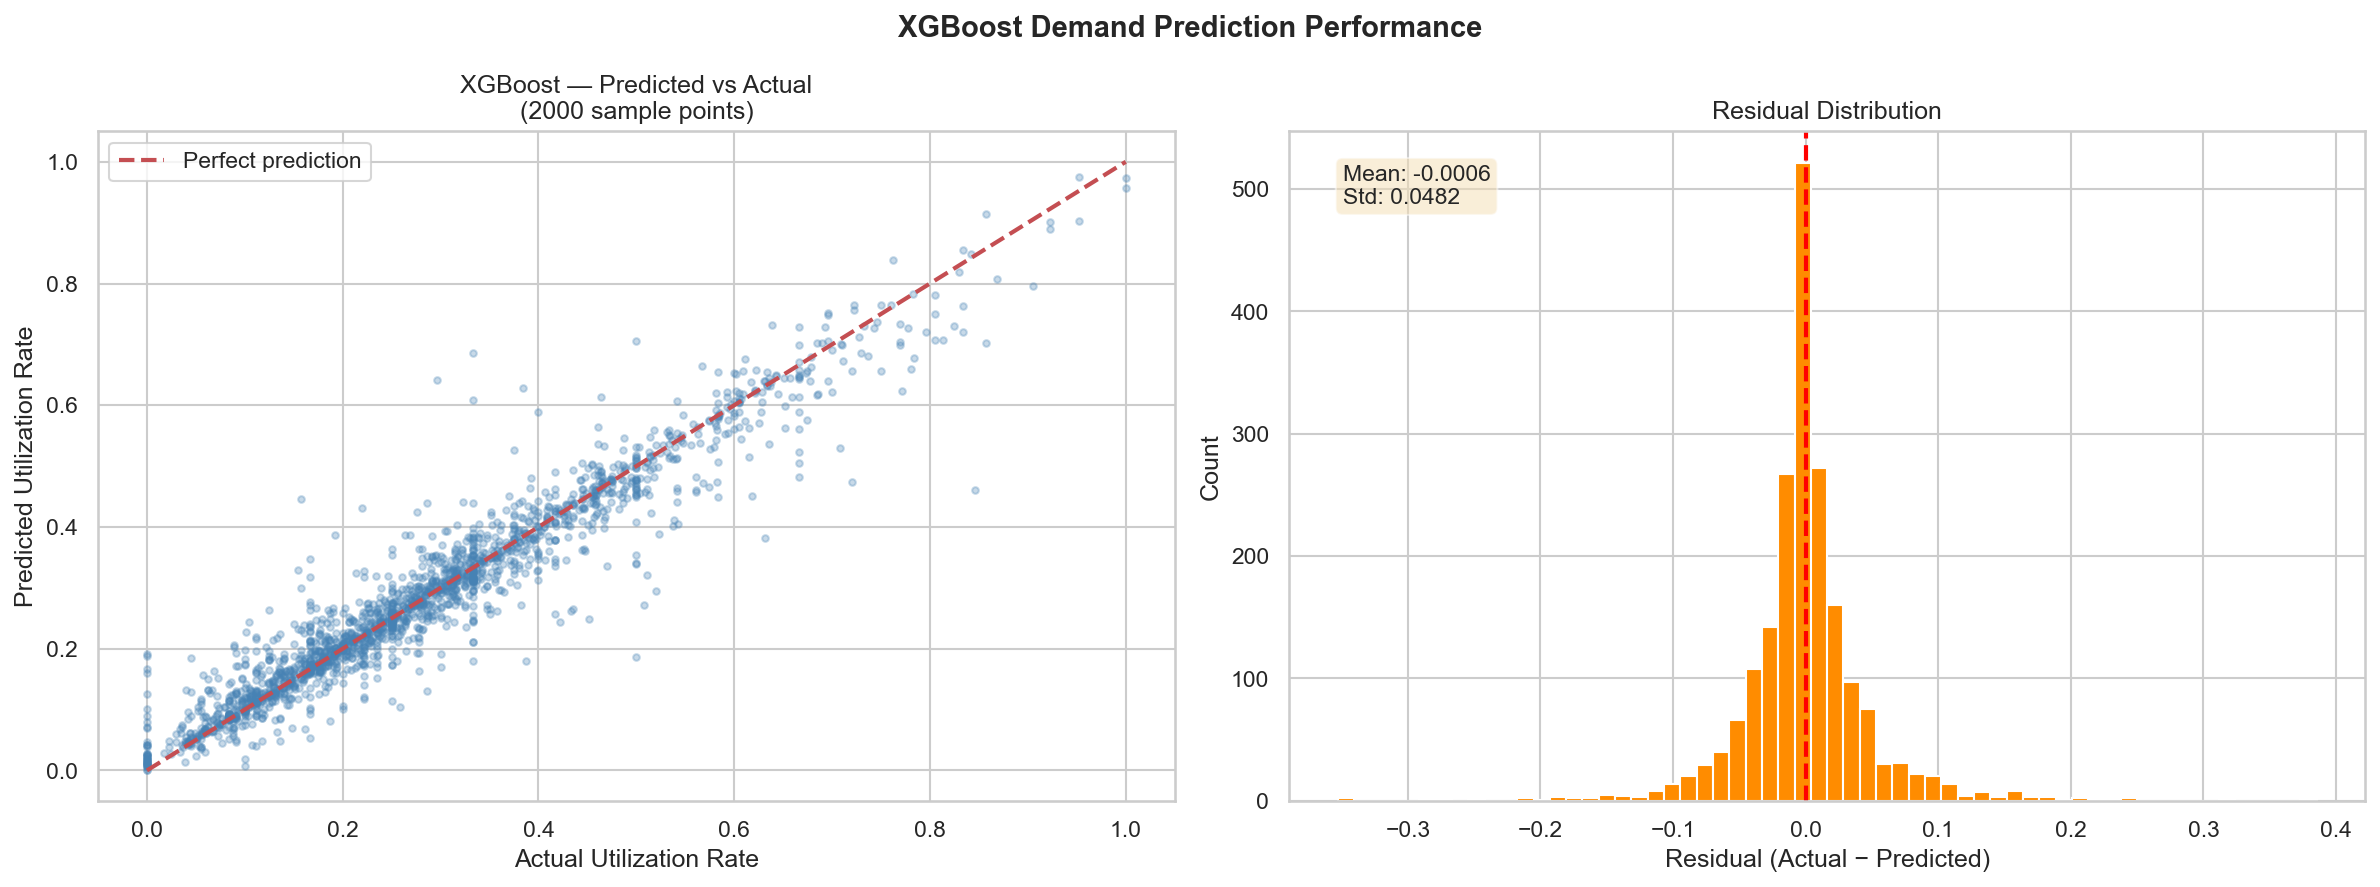

Saved: predicted_vs_actual.png


In [10]:
#Predicted vs actual plot
# Sample 2000 points for readability
sample_idx = np.random.choice(len(y_test), size=2000, replace=False)
y_sample   = np.array(y_test)[sample_idx]
p_sample   = best_preds[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: predicted vs actual
# Scatter plot shows how close the predictions follow the actual demands.
axes[0].scatter(y_sample, p_sample, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Utilization Rate')
axes[0].set_ylabel('Predicted Utilization Rate')
axes[0].set_title(f'{best_name} — Predicted vs Actual\n(2000 sample points)')
axes[0].legend()

# Residuals distribution
# This should be centered around 0 with small spread which confirms model is not
# over or under fitting.
residuals = y_sample - p_sample
axes[1].hist(residuals, bins=60, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].text(0.05, 0.95, f'Mean: {residuals.mean():.4f}\nStd: {residuals.std():.4f}',
             transform=axes[1].transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'{best_name} Demand Prediction Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/demand_agent/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: predicted_vs_actual.png")

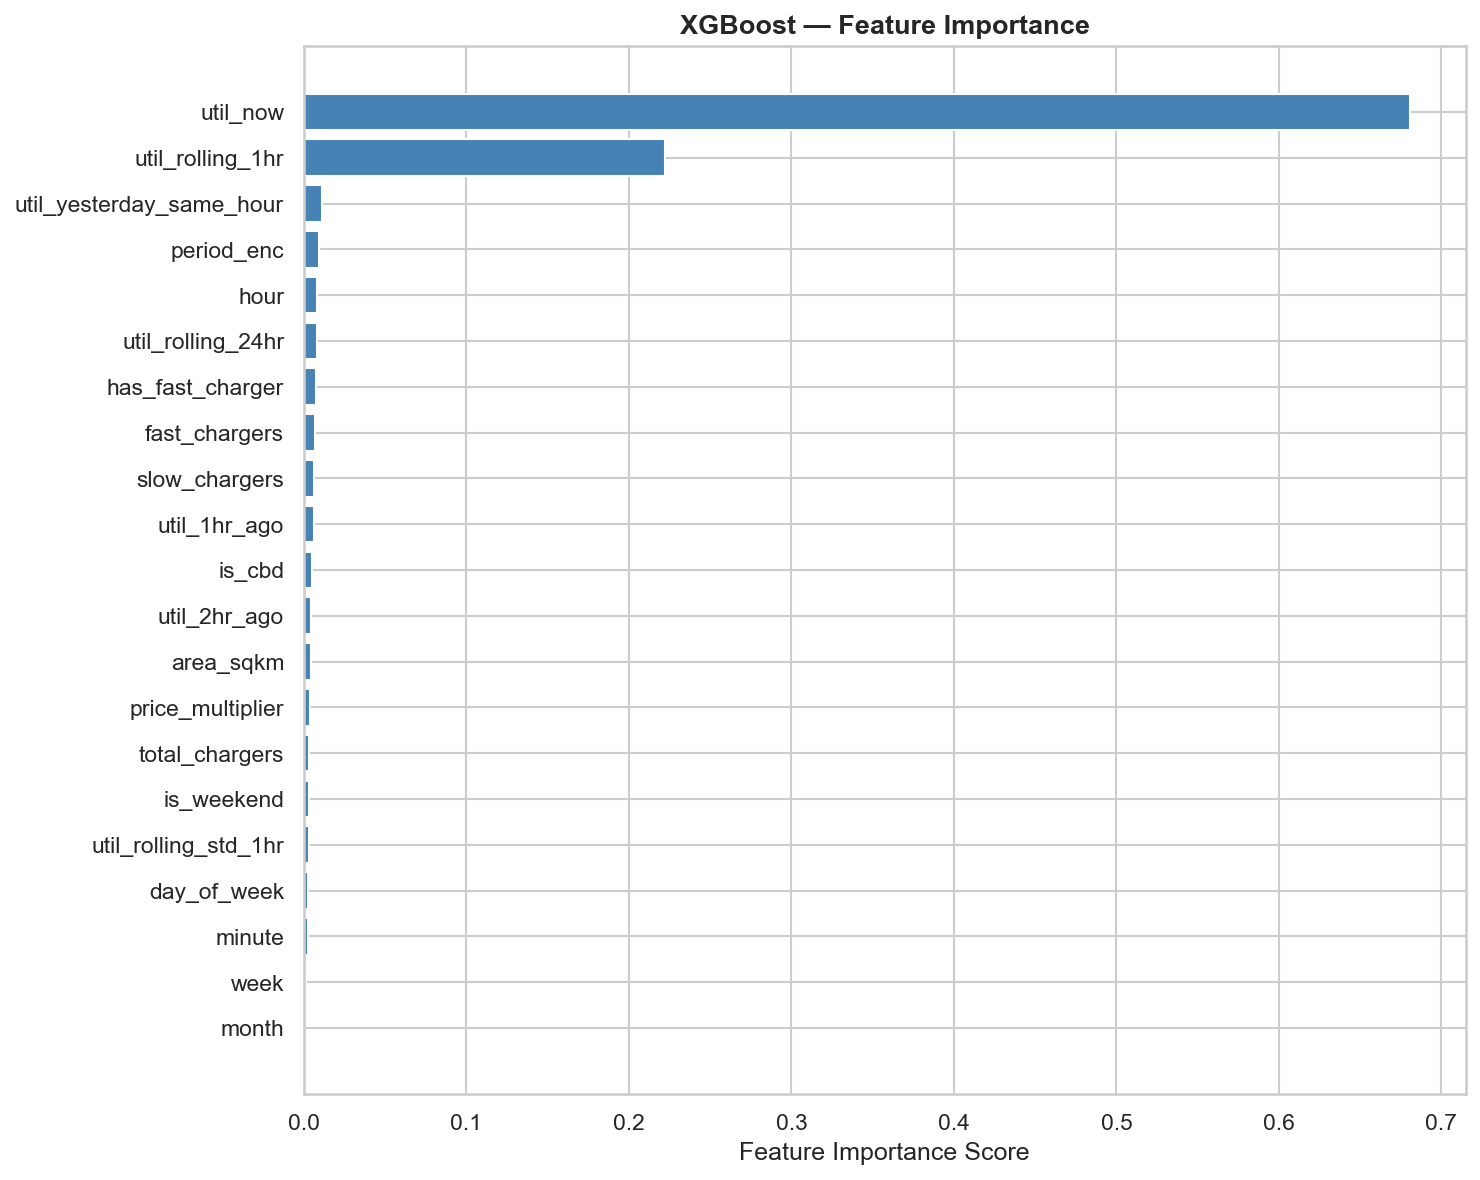

Saved: feature_importance.png

Top 5 most important features:
                 Feature  Importance
                    hour    0.008249
              period_enc    0.009135
util_yesterday_same_hour    0.011021
        util_rolling_1hr    0.222126
                util_now    0.680781


In [11]:
# Feature Importance
# Feature importance (only for tree-based models)

''' This explains which feature drives the demand prediction, and on which the tree-based model
relies the most.'''
if best_name in ['XGBoost', 'LightGBM', 'RandomForest']:
    
    importance = pd.DataFrame({
        'Feature':    feature_cols,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 8))
    bars = plt.barh(
        importance['Feature'],
        importance['Importance'],
        color='steelblue',
        edgecolor='white'
    )
    plt.xlabel('Feature Importance Score')
    plt.title(f'{best_name} — Feature Importance', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../visuals/demand_agent/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: feature_importance.png")
    
    # Print top 5
    print("\nTop 5 most important features:")
    print(importance.tail(5)[['Feature','Importance']].to_string(index=False))
else:
    print("Feature importance not available for Ridge regression")

In [12]:
# Addition of derived columns
'''These columns are generated because the congestion and underutilization flags 
directly trigger surge and discount pricing decisions respectively.'''

test_output = test[['datetime', 'station_id', 'hour', 'day_of_week',
                      'period_enc', 'is_weekend']].copy()

# Map period_enc back to readable label
period_map_reverse = {2: 'peak', 1: 'shoulder', 0: 'off_peak'}
test_output['period'] = test_output['period_enc'].map(period_map_reverse)

# Predicted utilization rate
test_output['predicted_utilization'] = best_preds

# Actual utilization for comparison
test_output['actual_utilization'] = y_test.values

# Congestion flag — predicted utilization > 80%
test_output['congestion_flag'] = (
    test_output['predicted_utilization'] > 0.8
).astype(int)

# Underutilization flag — predicted utilization < 30%
test_output['underutil_flag'] = (
    test_output['predicted_utilization'] < 0.3
).astype(int)

# Expected charging load proxy
avg_chargers = urban['total_chargers'].mean()
test_output['predicted_load_chargers'] = (
    test_output['predicted_utilization'] * avg_chargers
).round(2)

# Prediction error
test_output['prediction_error'] = (
    test_output['actual_utilization'] - test_output['predicted_utilization']
).round(5)

print("Prediction output shape:", test_output.shape)
print("\nSample predictions:")
print(test_output[['datetime', 'station_id', 'predicted_utilization',
                    'actual_utilization', 'congestion_flag',
                    'underutil_flag']].head(10).to_string(index=False))

Prediction output shape: (411996, 13)

Sample predictions:
           datetime  station_id  predicted_utilization  actual_utilization  congestion_flag  underutil_flag
2022-07-13 04:00:00         698               0.340266            0.333333                0               0
2022-07-13 04:00:00         577               0.206562            0.208333                0               1
2022-07-13 04:00:00         224               0.262149            0.262411                0               1
2022-07-13 04:00:00         986               0.582898            0.590909                0               0
2022-07-13 04:00:00         594               0.314799            0.315789                0               0
2022-07-13 04:00:00        1160               0.197255            0.000000                0               1
2022-07-13 04:00:00        1026               0.639141            0.516854                0               0
2022-07-13 04:00:00         587               0.263776            0.263158   

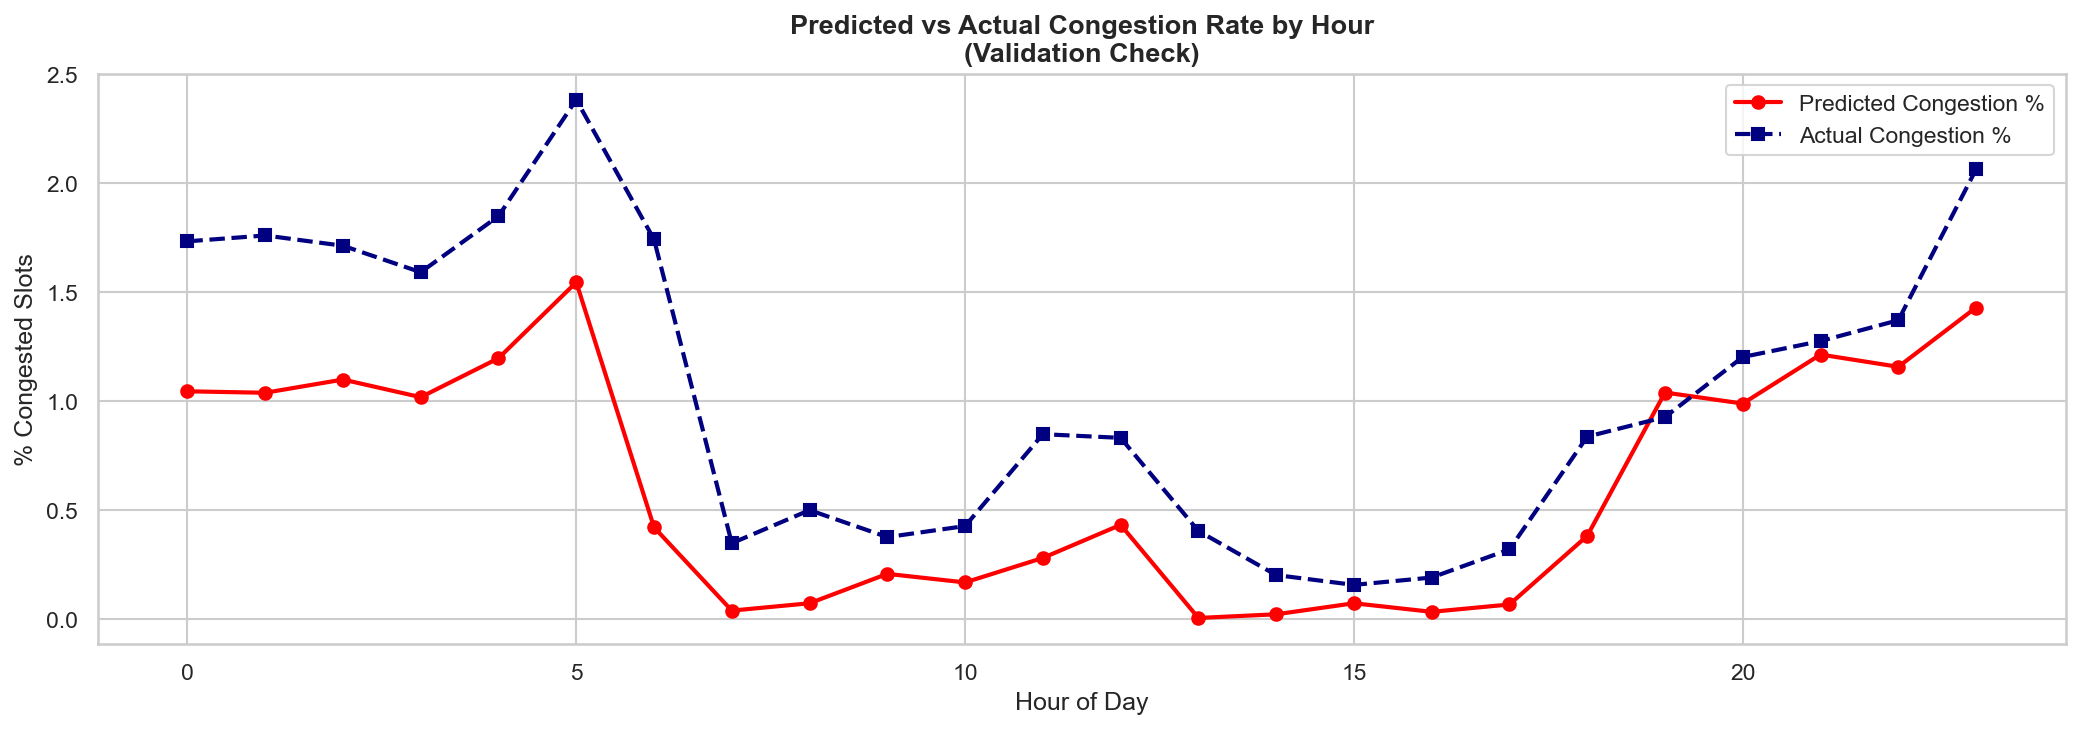

Saved: congestion_by_hour.png


In [13]:
# Congestion probability by hour validation:
# Check if our predictions make intuitive sense
# Peak hours should have higher congestion probability

cong_by_hour = test_output.groupby('hour').agg(
    pred_congestion_pct=('congestion_flag','mean'),
    actual_congestion_pct=('actual_utilization', lambda x: (x > 0.8).mean())
).reset_index()
cong_by_hour *= 100
cong_by_hour['hour'] = test_output.groupby('hour')['hour'].first().values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cong_by_hour['hour'], cong_by_hour['pred_congestion_pct'],
        marker='o', color='red', linewidth=2, label='Predicted Congestion %')
ax.plot(cong_by_hour['hour'], cong_by_hour['actual_congestion_pct'],
        marker='s', color='navy', linewidth=2, linestyle='--', label='Actual Congestion %')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('% Congested Slots')
ax.set_title('Predicted vs Actual Congestion Rate by Hour\n(Validation Check)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../visuals/demand_agent/congestion_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: congestion_by_hour.png")

In [14]:
# Export Demand Predictions CSV for demand prediction agent.
test_output.to_csv('../outputs/demand_agent/demand_predictions.csv', index=False)
print("Saved: demand_predictions.csv →", test_output.shape)

# Summary statistics
print("\n=== Prediction Summary ===")
print(f"Total test slots predicted:     {len(test_output):,}")
print(f"Congested slots (>80%):         {test_output['congestion_flag'].sum():,} ({test_output['congestion_flag'].mean()*100:.1f}%)")
print(f"Underutilized slots (<30%):     {test_output['underutil_flag'].sum():,} ({test_output['underutil_flag'].mean()*100:.1f}%)")
print(f"Avg predicted utilization:      {test_output['predicted_utilization'].mean():.4f}")
print(f"Avg actual utilization:         {test_output['actual_utilization'].mean():.4f}")

print("\nNotebook 3 Complete!")

Saved: demand_predictions.csv → (411996, 13)

=== Prediction Summary ===
Total test slots predicted:     411,996
Congested slots (>80%):         2,499 (0.6%)
Underutilized slots (<30%):     244,114 (59.3%)
Avg predicted utilization:      0.2883
Avg actual utilization:         0.2890

Notebook 3 Complete!
